In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [9]:
!pip install openpyxl

df = pd.read_excel(r"E:\DATA sCIENCE\Data set\heart_disease (1).xlsx")
df



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [10]:
xls = pd.ExcelFile(r"E:\DATA sCIENCE\Data set\heart_disease (1).xlsx")
xls.sheet_names

['Description', 'Heart_disease']

In [13]:
df = pd.read_excel(xls, sheet_name='Heart_disease')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


2. Exploratory Data Analysis (EDA):

   Perform exploratory data analysis to understand the structure of the dataset.


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [17]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Check for missing values, outliers, and inconsistencies in the data.

In [16]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

Visualize the distribution of features, including histograms, box plots, and correlation matrices.

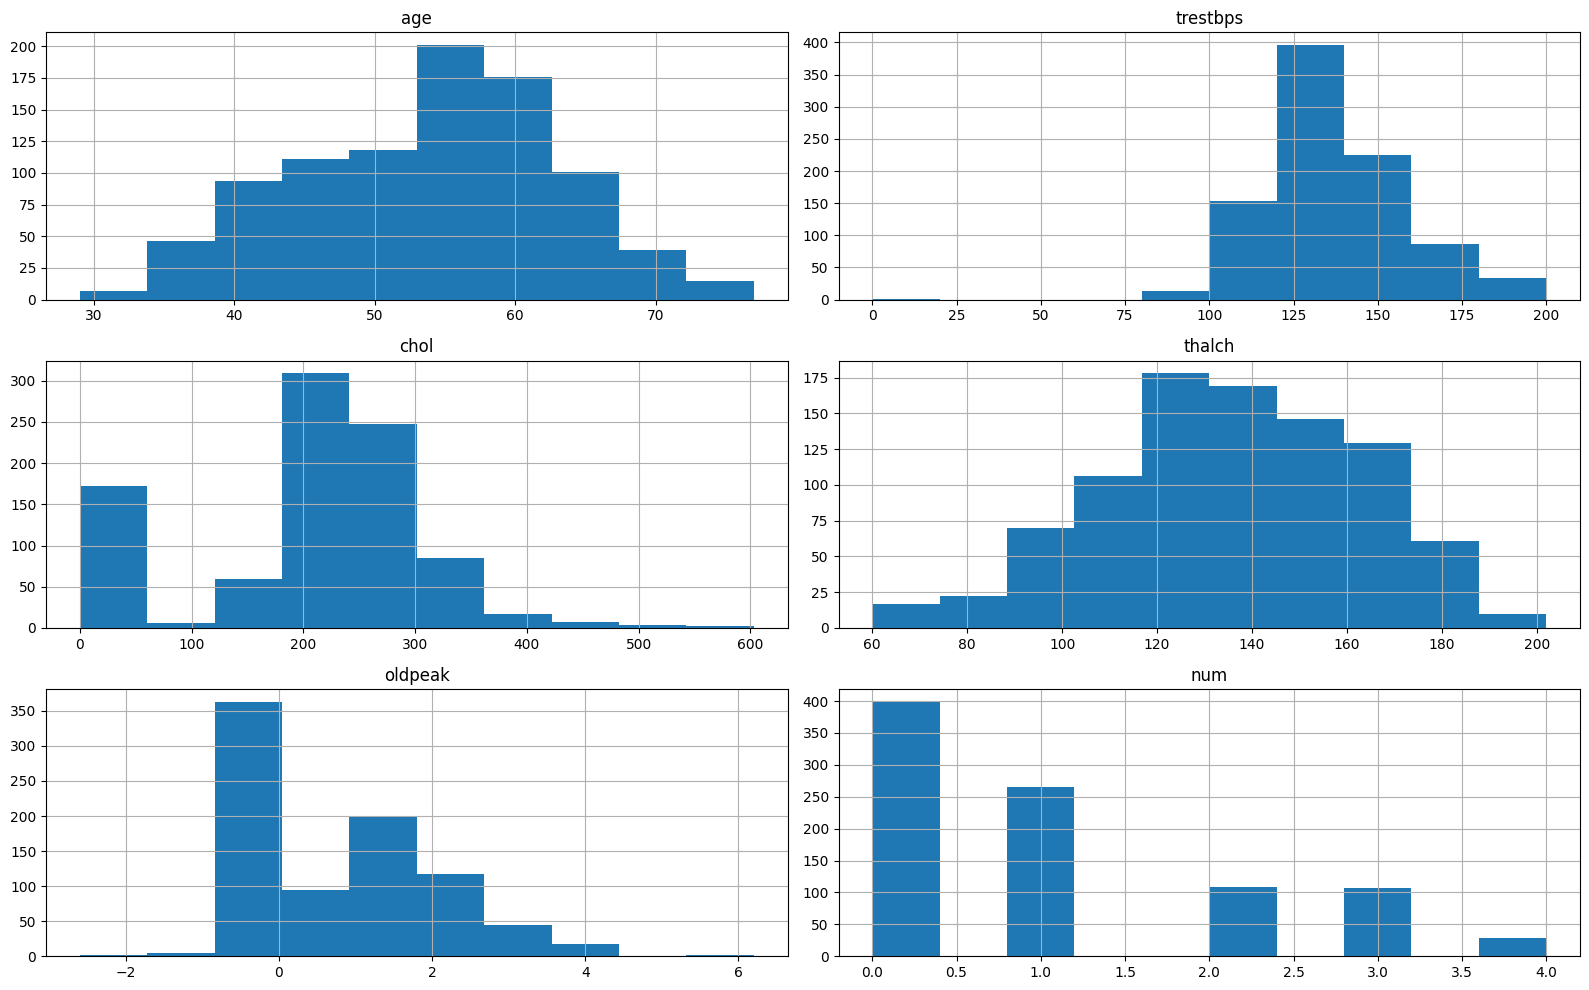

In [18]:
df.hist(figsize = (16,10))
plt.tight_layout()
plt.show()

[]

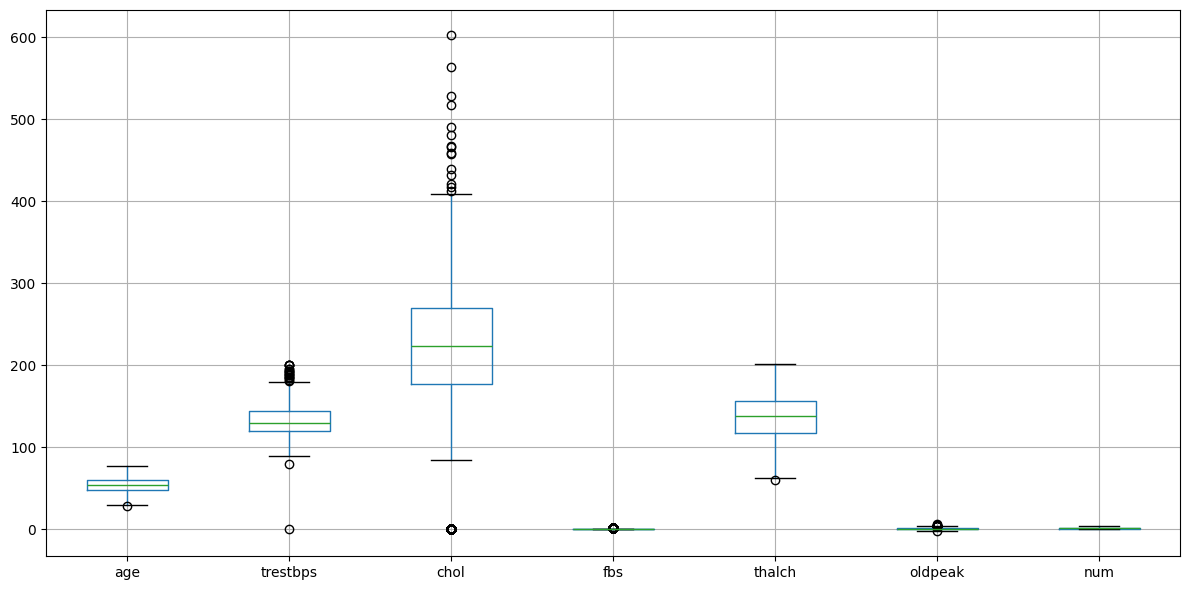

In [20]:
df.boxplot(figsize=(12,6))
plt.tight_layout()
plt.plot()

In [67]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [68]:
X['oldpeak'].fillna(X['oldpeak'].median(), inplace=True)
X.isnull().sum()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17388\3757635192.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['oldpeak'].fillna(X['oldpeak'].median(), inplace=True)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
dtype: int64

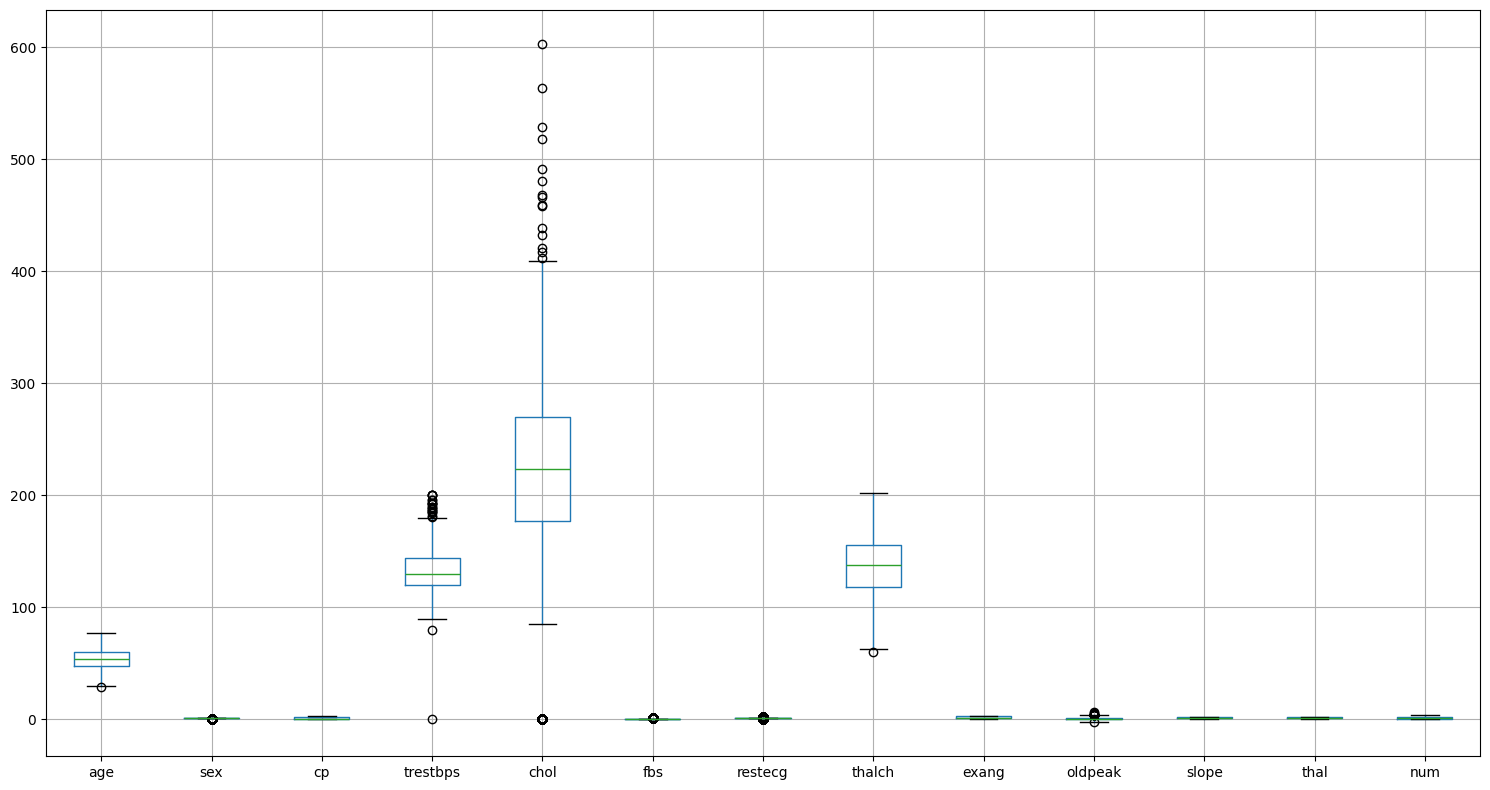

In [69]:
df.boxplot(figsize = (15,8))
plt.tight_layout()
plt.show()

<Axes: >

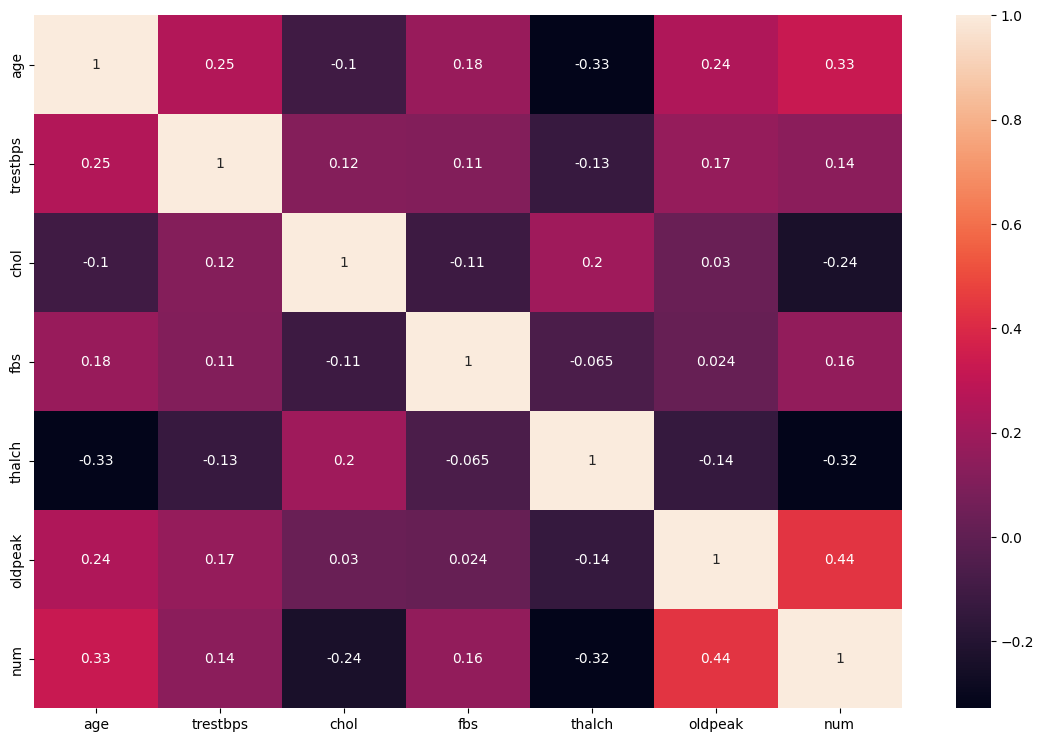

In [21]:
plt.figure(figsize=(14,9))
sns.heatmap(df.corr(numeric_only = True), annot = True)

3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include = ['object','bool']).columns:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [42]:
from sklearn.preprocessing import StandardScaler
X = df.drop('num', axis=1)
y = df['num']

scaler = StandardScaler()
SS_X = scaler.fit_transform(X)
SS_X = pd.DataFrame(SS_X, columns = X.columns)
print(SS_X)

          age       sex        cp  trestbps      chol       fbs   restecg  \
0    1.006027  0.514416  2.320276  0.567394  0.281297  1.976894 -1.561352   
1   -1.397560  0.514416  0.232258  0.076967  0.013526 -0.505844  0.013879   
2    0.350503  0.514416 -0.811752  0.322181 -0.084656 -0.505844  0.013879   
3   -0.195767  0.514416  2.320276 -0.756760 -0.138211 -0.505844 -1.561352   
4    0.350503  0.514416 -0.811752 -1.149102 -0.004325 -0.505844  0.013879   
..        ...       ...       ...       ...       ...       ...       ...   
903 -0.086513  0.514416 -0.811752 -0.413461 -1.798388 -0.505844  0.013879   
904  0.896773  0.514416 -0.811752  1.597292 -0.281021 -0.505844  1.589110   
905  0.241249  0.514416  1.276267  1.793463 -1.798388 -0.505844 -1.561352   
906  0.241249  0.514416  1.276267  0.518352  0.058155  1.976894  1.589110   
907  0.350503  0.514416 -0.811752  0.420266  0.674027  1.976894  1.589110   

       thalch     exang   oldpeak     slope      thal  
0    0.524183 -0.77

4. Decision Tree Classification:
   
Split the dataset into training and testing sets (e.g., using an 80-20 split).


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
Implement a Decision Tree Classification model using a library like scikit-learn.

In [59]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(criterion = 'gini')
DT.fit(X_train, y_train)

y_pred_train = DT.predict(X_train)
y_pred_test = DT.predict(X_test)

Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [60]:
from sklearn.metrics import accuracy_score, log_loss
training_accuracy  = accuracy_score(y_train,y_pred_train)
test_accuracy  = accuracy_score(y_test,y_pred_test)
print(" Training Accuracy:", training_accuracy)
print("Test Accuracy:", test_accuracy)

 Training Accuracy: 0.9972451790633609
Test Accuracy: 0.489010989010989


In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, classification_report, confusion_matrix
precision = precision_score(y_test, y_pred_test, average = 'weighted')
recall = recall_score(y_test, y_pred_test, average= 'weighted')
f1 = f1_score(y_test, y_pred_test, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


Precision: 0.48252114186180123
Recall: 0.489010989010989
F1-Score: 0.48494359001014353


5. Hyperparameter Tuning:

Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [5, 7, 10, 15],
    'min_samples_leaf': [4, 6, 8, 10]
}

model_para = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=model_para, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_test_best = best_model.predict(X_test)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)
print("Test accuracy of best model:", test_accuracy_best)

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 15}
Best score: 0.5467926310817195
Test accuracy of best model: 0.5769230769230769


6. Model Evaluation and Analysis:

Analyse the performance of the Decision Tree model using the evaluation metrics obtained.


Accuracy: 0.5769230769230769

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.84      0.78        89
           1       0.40      0.52      0.45        48
           2       0.50      0.14      0.21        22
           3       0.22      0.12      0.15        17
           4       0.00      0.00      0.00         6

    accuracy                           0.58       182
   macro avg       0.37      0.32      0.32       182
weighted avg       0.54      0.58      0.54       182


Confusion Matrix:



C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

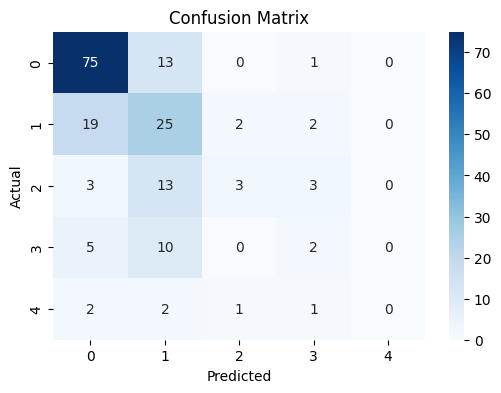

In [77]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Visualize the decision tree structure to understand the rules learned by the model and identify important features

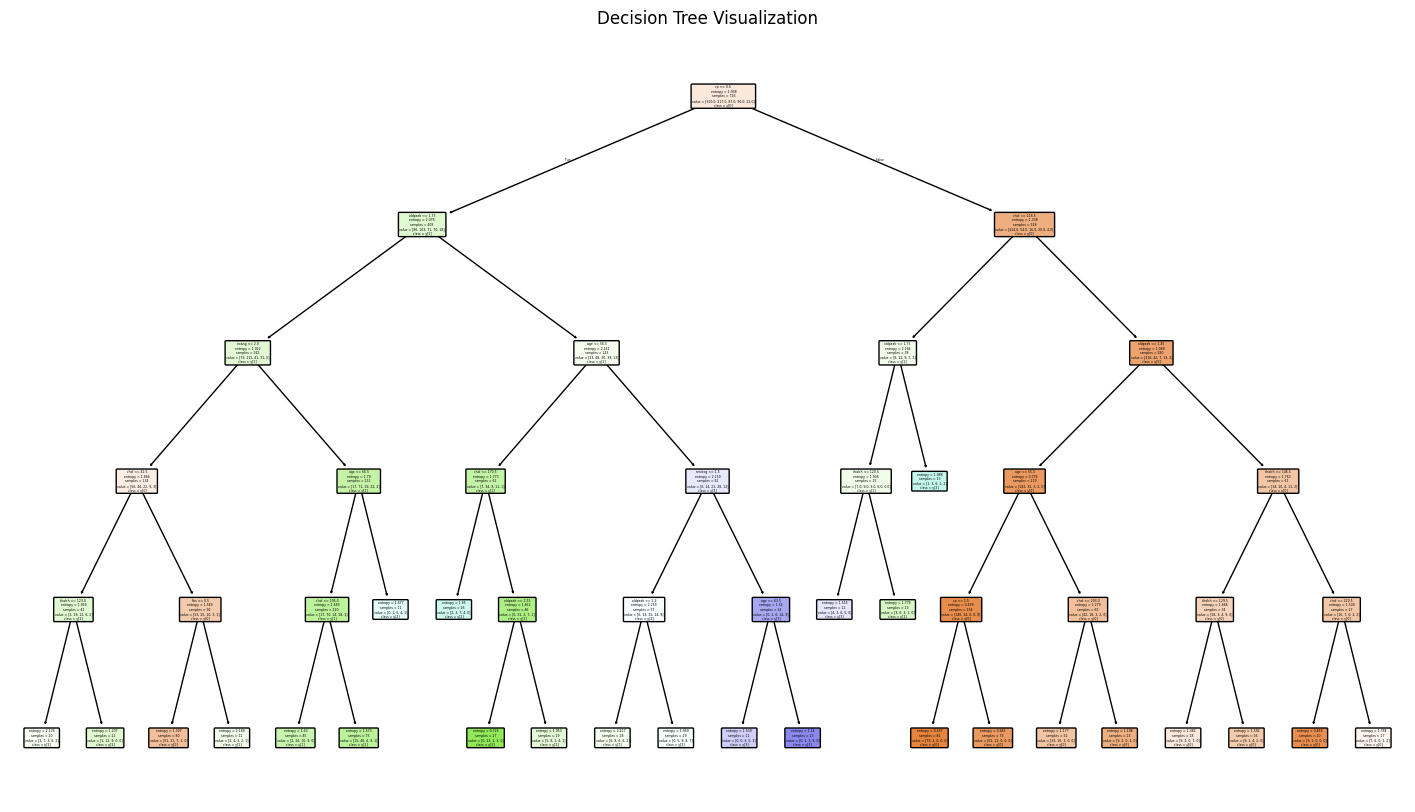

In [78]:
#Visualize the decision tree structure to understand the rules learned by the model and identify important features
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(best_model, filled=True, feature_names=X.columns, class_names=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

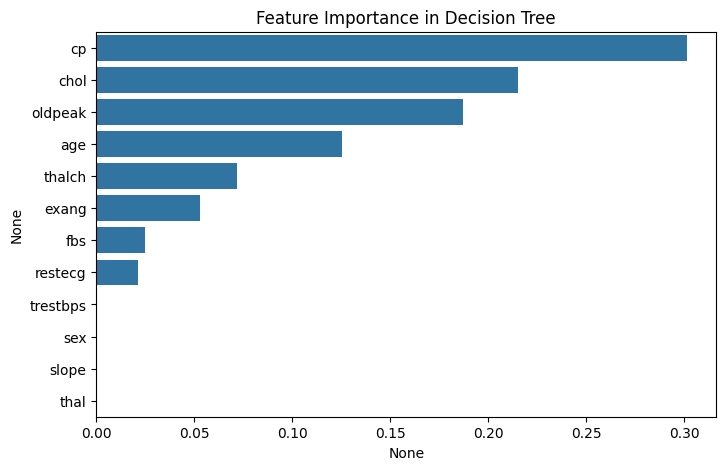

In [79]:
#identify important features
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance in Decision Tree")
plt.show()

Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
    max_depth – limits how deep the tree can grow; prevents overfitting.
    min_samples_split – minimum samples to split a node; higher value reduces overfitting.
    min_samples_leaf – minimum samples per leaf; makes model more general.
    criterion – measures split quality (e.g., gini, entropy).
    max_features – number of features to consider per split; controls randomness and overfitting.



2. What is the difference between the Label encoding and One-hot encoding?

    Label Encoding:
    Converts categories into numeric labels 
    Used for ordinal data (where order matters).
    May cause algorithms to assume a numeric relationship between categories.

    One-Hot Encoding:
    Creates separate binary columns for each category 
    Used for nominal data (no order).
    Avoids giving false numeric relationships between categories.